In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df = pd.read_csv(r'C:\Users\i242552\Desktop\Sample - Superstore.csv', encoding='latin1')

In [17]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


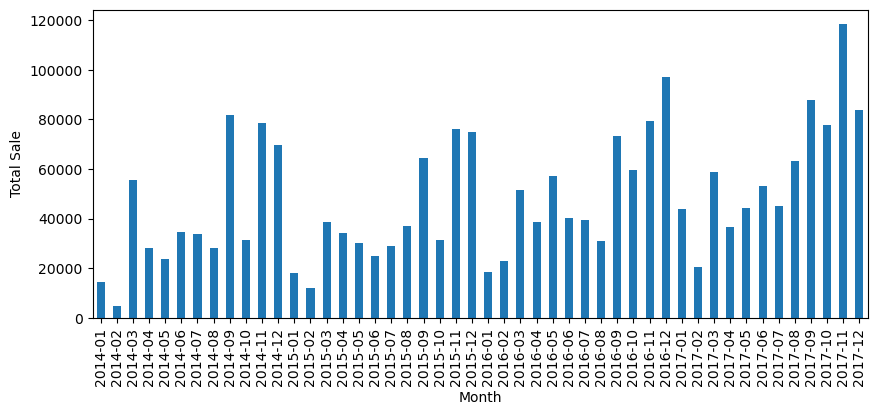

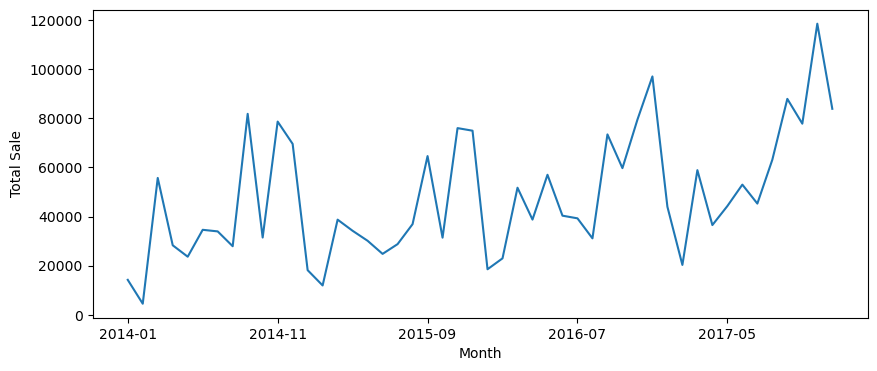

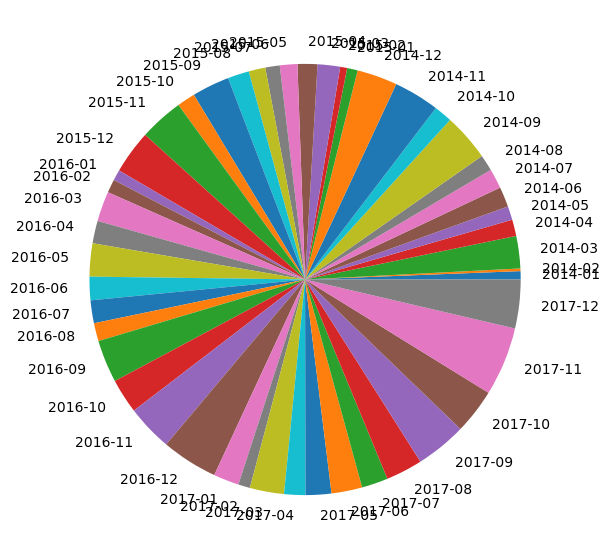

In [29]:
#task 1

df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().sort_index()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10, 4))
monthly_sales.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Total Sale')
plt.show()

plt.figure(figsize=(10, 4))
monthly_sales.plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Total Sale')
plt.show()

plt.figure(figsize=(7, 7))
monthly_sales.plot(kind='pie')
plt.ylabel('')
plt.show()

#Line chart is best because it shows overall trend properly as one line that rises up or down 
#that higher peak has higher sales that day bar is to compare months with each other
#pie chart hides the trend because you cannot tell how it has increased/decrease over the months you need to manually check and remember which month had what

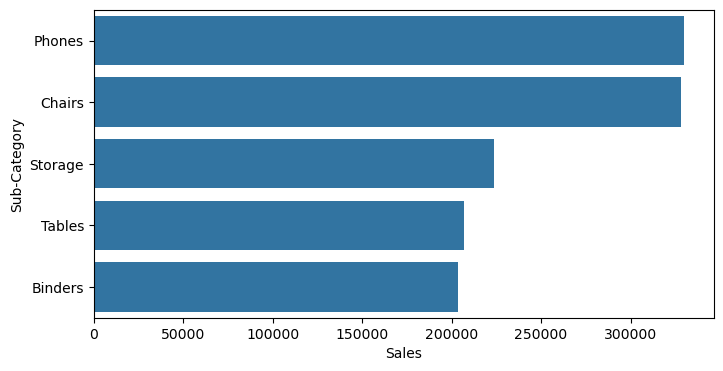

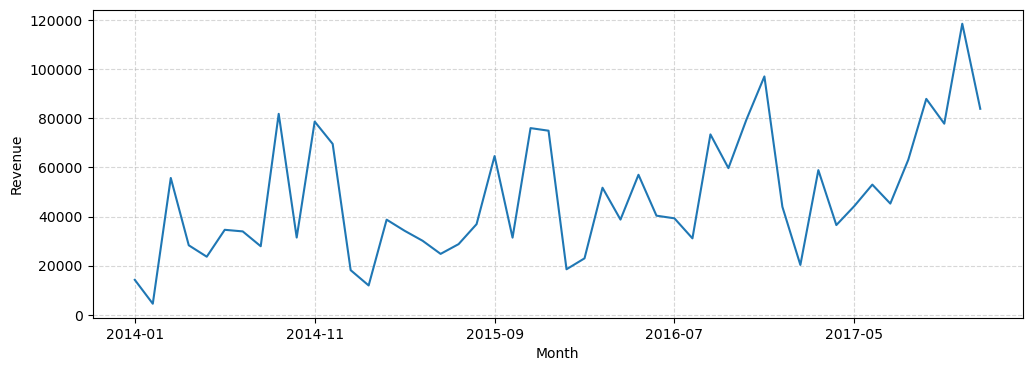

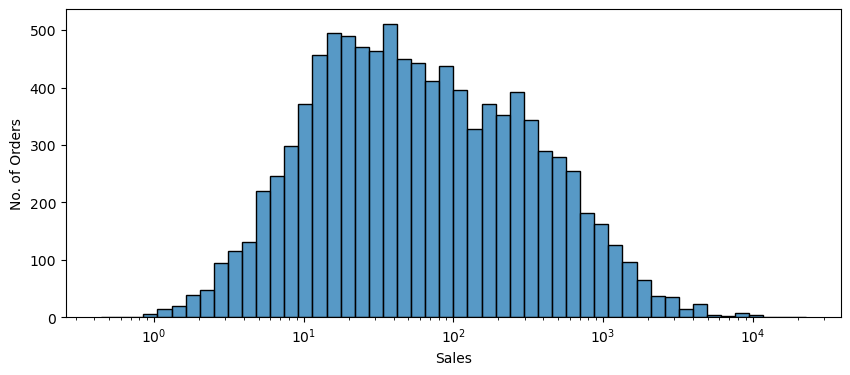

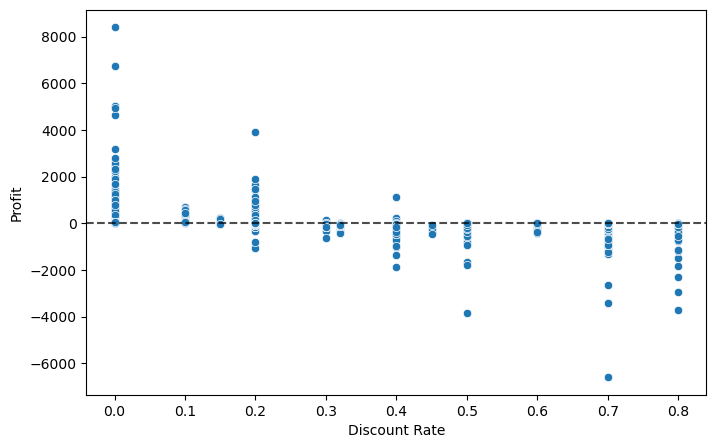

In [43]:
#task 2

top5 = df.groupby('Sub-Category')['Sales'].sum().nlargest(5).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=top5, x='Sales', y='Sub-Category')
plt.show()

#bar chart is best as you can directly just compare their heights and check which category has highest sale
#line chart shows overall trend better it is not good for direct comparison


plt.figure(figsize=(12, 4))
monthly_sales.plot(kind='line')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#again since this is trend then line chart shows the overall trend the best
#bar chart somewhat shows trend but it is again like task 1 we will have to check heights of each bar against each other


plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Sales', bins=50, log_scale=True)
plt.xlabel('Sales')
plt.ylabel('No. of Orders')
plt.show()

#since we are showing distribution then a histogram shows it the best
#if we used pie chart there is no way to tell how the data may be skewed or how high the peak of the data is


plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.xlabel('Discount Rate')
plt.ylabel('Profit')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.show()


#scatter plot is the best here because we are showing the relationship between two columns
#so ecah point denotes that at some x value the y value was y
#pie chart or bar chart cannot accurately show this as they are for size comparisons with other data points, not x against y



C:\Users\i242552\AppData\Local\Temp\ipykernel_5884\607661996.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set2')


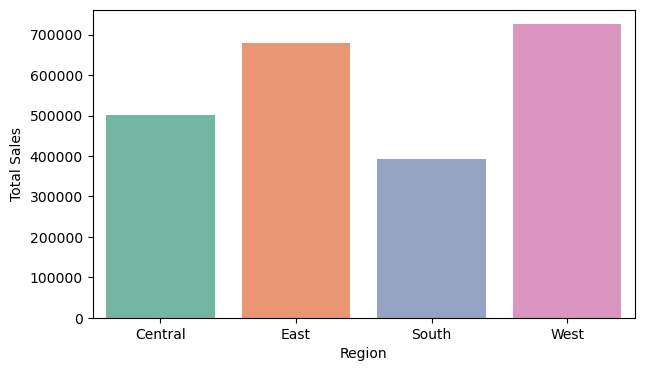

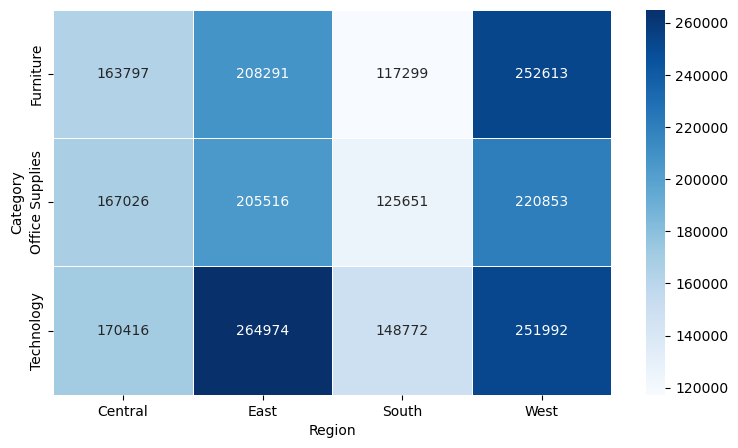

C:\Users\i242552\AppData\Local\Temp\ipykernel_5884\607661996.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_profit, x='Order Date', y='Profit', palette=bar_colors)


Text(0.5, 0, 'Month')

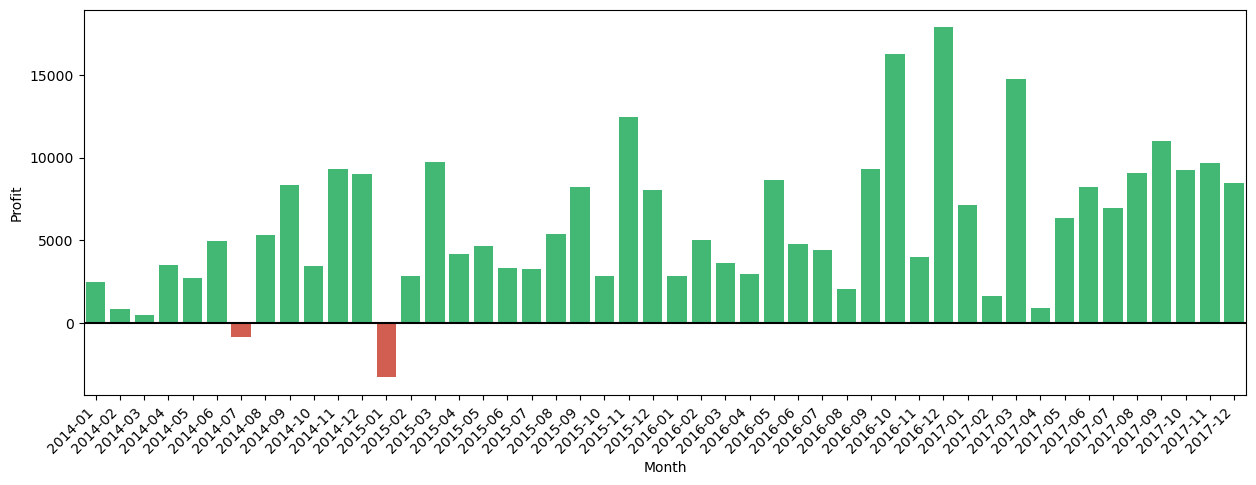

In [65]:
#task 3

region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=region_sales, x='Region', y='Sales', palette='Set2')
plt.ylabel('Total Sales')
plt.show()


groupby_grid = df.groupby(['Category', 'Region'])['Sales'].sum().unstack()
plt.figure(figsize=(9, 5))
sns.heatmap(groupby_grid, annot=True, fmt=".0f", cmap='Blues', linewidths=0.5)
plt.show()



df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum().sort_index()
monthly_profit = monthly_profit.reset_index()
monthly_profit['Order Date'] = monthly_profit['Order Date'].astype(str)

plt.figure(figsize=(15, 5))

#this maps positive numbers to Green and negative numbers to Red manually because center does not work on this version of seaborn
bar_colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in monthly_profit['Profit']]

sns.barplot(data=monthly_profit, x='Order Date', y='Profit', palette=bar_colors)
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=1.5)
plt.ylabel('Profit')
plt.xlabel('Month')



In [56]:
!pip install --upgrade --user seaborn


Access is denied.


In [66]:
#task 4


import numpy as np

def wcag_contrast_ratio(color_hex, background_hex="#ffffff"):
    """
    Computes the WCAG 2.1 contrast ratio between a text/element color 
    and a background color (defaults to standard Jupyter white).
    """
    def get_luminance(hex_str):
        # Convert hex string to raw normalized rgb floats
        hex_str = hex_str.lstrip('#')
        rgb = [int(hex_str[i:i+2], 16) / 255.0 for i in (0, 2, 4)]
        
        # Apply standard sRGB gamma linearization expansion
        linear_rgb = [
            c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 
            for c in rgb
        ]
        # Weighted coefficients representing human visual spectral sensitivity
        return 0.2126 * linear_rgb[0] + 0.7152 * linear_rgb[1] + 0.0722 * linear_rgb[2]

    l1 = get_luminance(color_hex)
    l2 = get_luminance(background_hex)
    
    # Standard formula structure: (Lighter + 0.05) / (Darker + 0.05)
    ratio = (l1 + 0.05) / (l2 + 0.05) if l1 > l2 else (l2 + 0.05) / (l1 + 0.05)
    return round(ratio, 2)

# --- Verification Test ---
task_3_colors = {
    "Task 3(c) Positive Green": "#2ecc71",
    "Task 3(c) Negative Red": "#e74c3c"
}

print("=== WCAG 2.1 Contrast Check (Target Minimum -> 4.5:1 AA) ===")
for label, hex_code in task_3_colors.items():
    ratio = wcag_contrast_ratio(hex_code, background_hex="#ffffff")
    status = "PASSED ✅" if ratio >= 4.5 else "FAILED ❌ (FLAGGED)"
    print(f"{label} ({hex_code}): {ratio}:1 Ratio -> {status}")

=== WCAG 2.1 Contrast Check (Target Minimum -> 4.5:1 AA) ===
Task 3(c) Positive Green (#2ecc71): 2.1:1 Ratio -> FAILED ❌ (FLAGGED)
Task 3(c) Negative Red (#e74c3c): 3.82:1 Ratio -> FAILED ❌ (FLAGGED)


C:\Users\i242552\AppData\Local\Temp\ipykernel_5884\2992360130.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=sub_profit, x='Sub-Category', y='Profit', palette=colors)


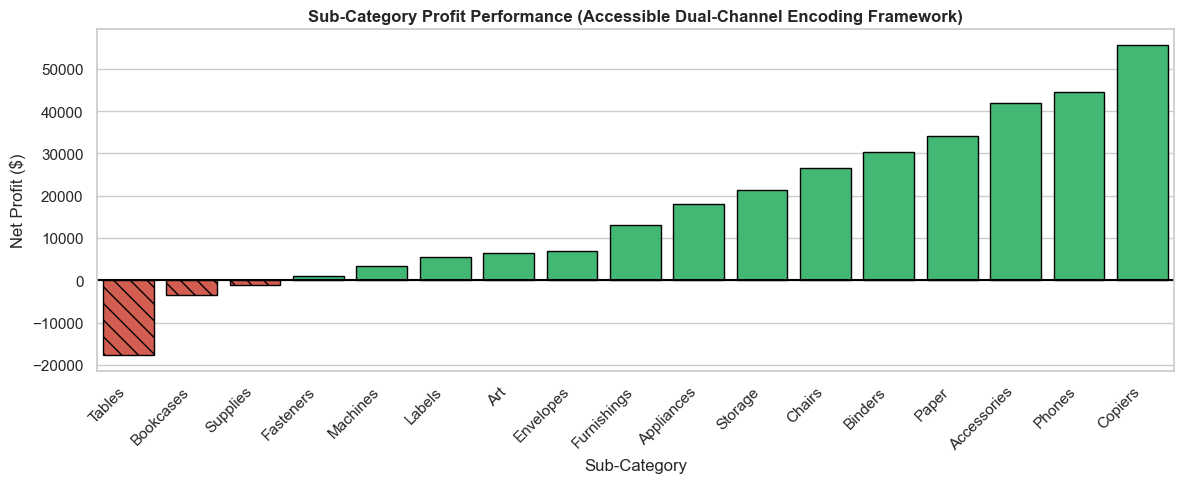

C:\Users\i242552\AppData\Local\Temp\ipykernel_5884\2992360130.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


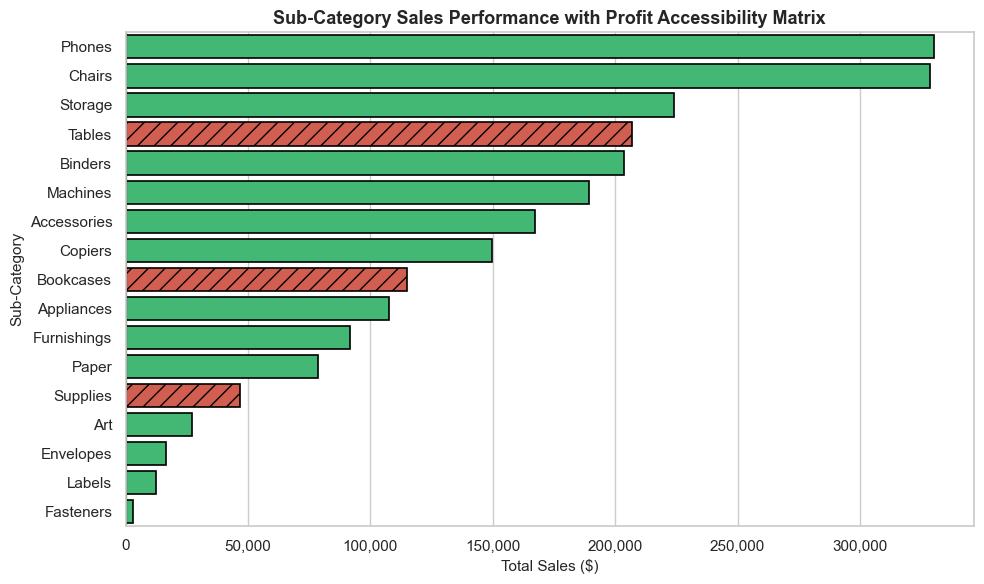

In [69]:
# Mocking the provided sub-category profit data vector 
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values().reset_index()

plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

# Create arrays for native properties 
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in sub_profit['Profit']]

# Generate custom structural arrays to preserve content if colors go monochromatic
# Positive bars receive a solid appearance; negative bars get strong downward diagonal lines
hatch_patterns = ['' if x >= 0 else '\\\\' for x in sub_profit['Profit']]

# Draw the base structural plot configuration
bar_plot = sns.barplot(data=sub_profit, x='Sub-Category', y='Profit', palette=colors)

# Loop over structural canvas patch components to hard-overlay hatching layouts
for patch, pattern in zip(bar_plot.patches, hatch_patterns):
    patch.set_hatch(pattern)
    patch.set_edgecolor('black') # Dark perimeter outlines preserve contrast context

# Final decoration metrics
plt.axhline(0, color='black', linewidth=1.5)
plt.xticks(rotation=45, ha='right')
plt.title('Sub-Category Profit Performance (Accessible Dual-Channel Encoding Framework)', fontweight='bold')
plt.ylabel('Net Profit ($)')
plt.tight_layout()

plt.show()





import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set clean white background grid style
sns.set_theme(style="whitegrid")

# 1. Aggregate both Sales and Profit by Sub-Category to determine performance
subcat_perf = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().reset_index()

# Sort by Sales value so the horizontal chart flows cleanly from largest to smallest
subcat_perf = subcat_perf.sort_values(by='Sales', ascending=False)

# 2. Set up dimensions for a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create the base color list for the bars (Green for Profit >= 0, Red for Loss < 0)
bar_colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in subcat_perf['Profit']]

# 4. Generate the base barplot using Sales as the bar length
sns.barplot(
    data=subcat_perf, 
    x='Sales', 
    y='Sub-Category', 
    palette=bar_colors, 
    ax=ax,
    edgecolor='black', # Add clear black borders around all bars
    linewidth=1.2
)

# 5. Accessibility Modification: Add diagonal hatching texturing to negative profit bars
# We loop through each individual drawn bar patch to apply texture rules
for i, bar in enumerate(ax.patches):
    # Check if this specific sub-category has a negative profit
    if subcat_perf['Profit'].iloc[i] < 0:
        bar.set_hatch('//')         # Applies diagonal hatch lines
        bar.set_edgecolor('black')  # Ensures hatch lines and borders are crisp black

# 6. Formatting structural layout elements
plt.axvline(0, color='black', linewidth=1.5) # Hard zero baseline boundary
ax.set_title('Sub-Category Sales Performance with Profit Accessibility Matrix', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.set_ylabel('Sub-Category', fontsize=11)

# Format x-axis with comma separators for clean financial reading
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

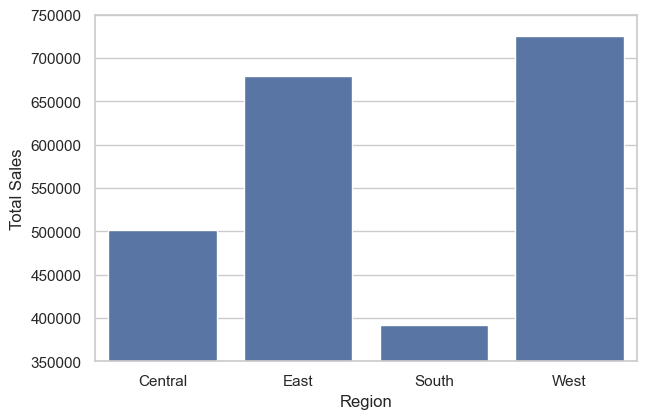

C:\Users\i242552\AppData\Local\Temp\ipykernel_5884\607328817.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly_data.index, rotation=45, ha='right')


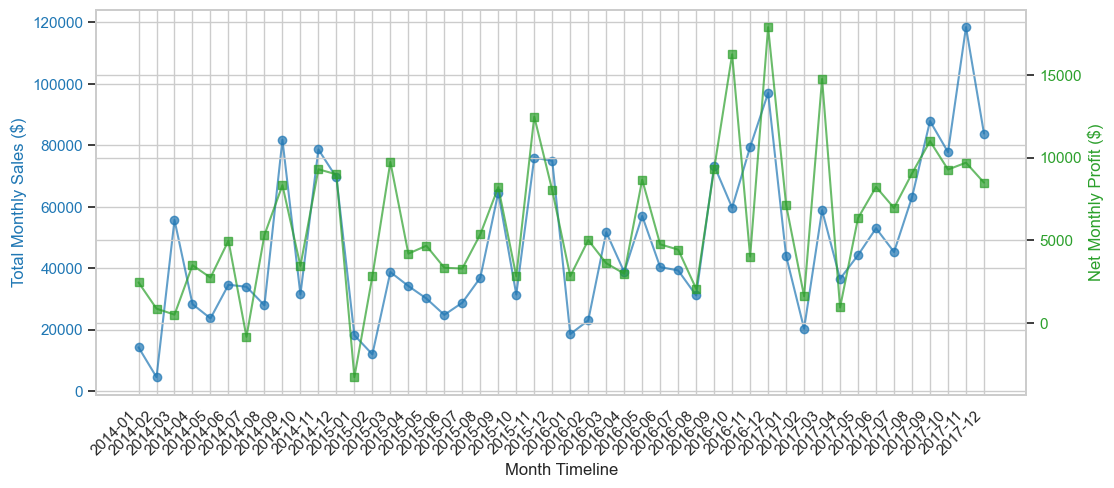

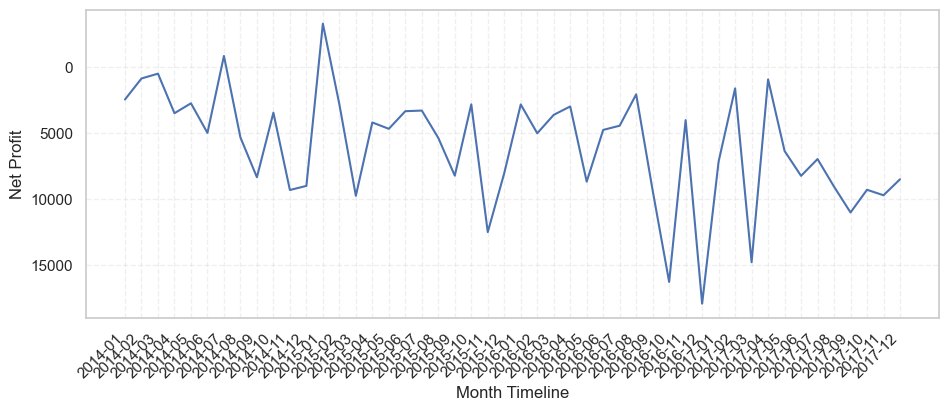

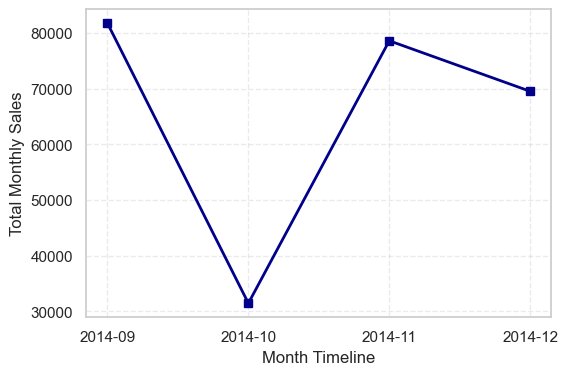

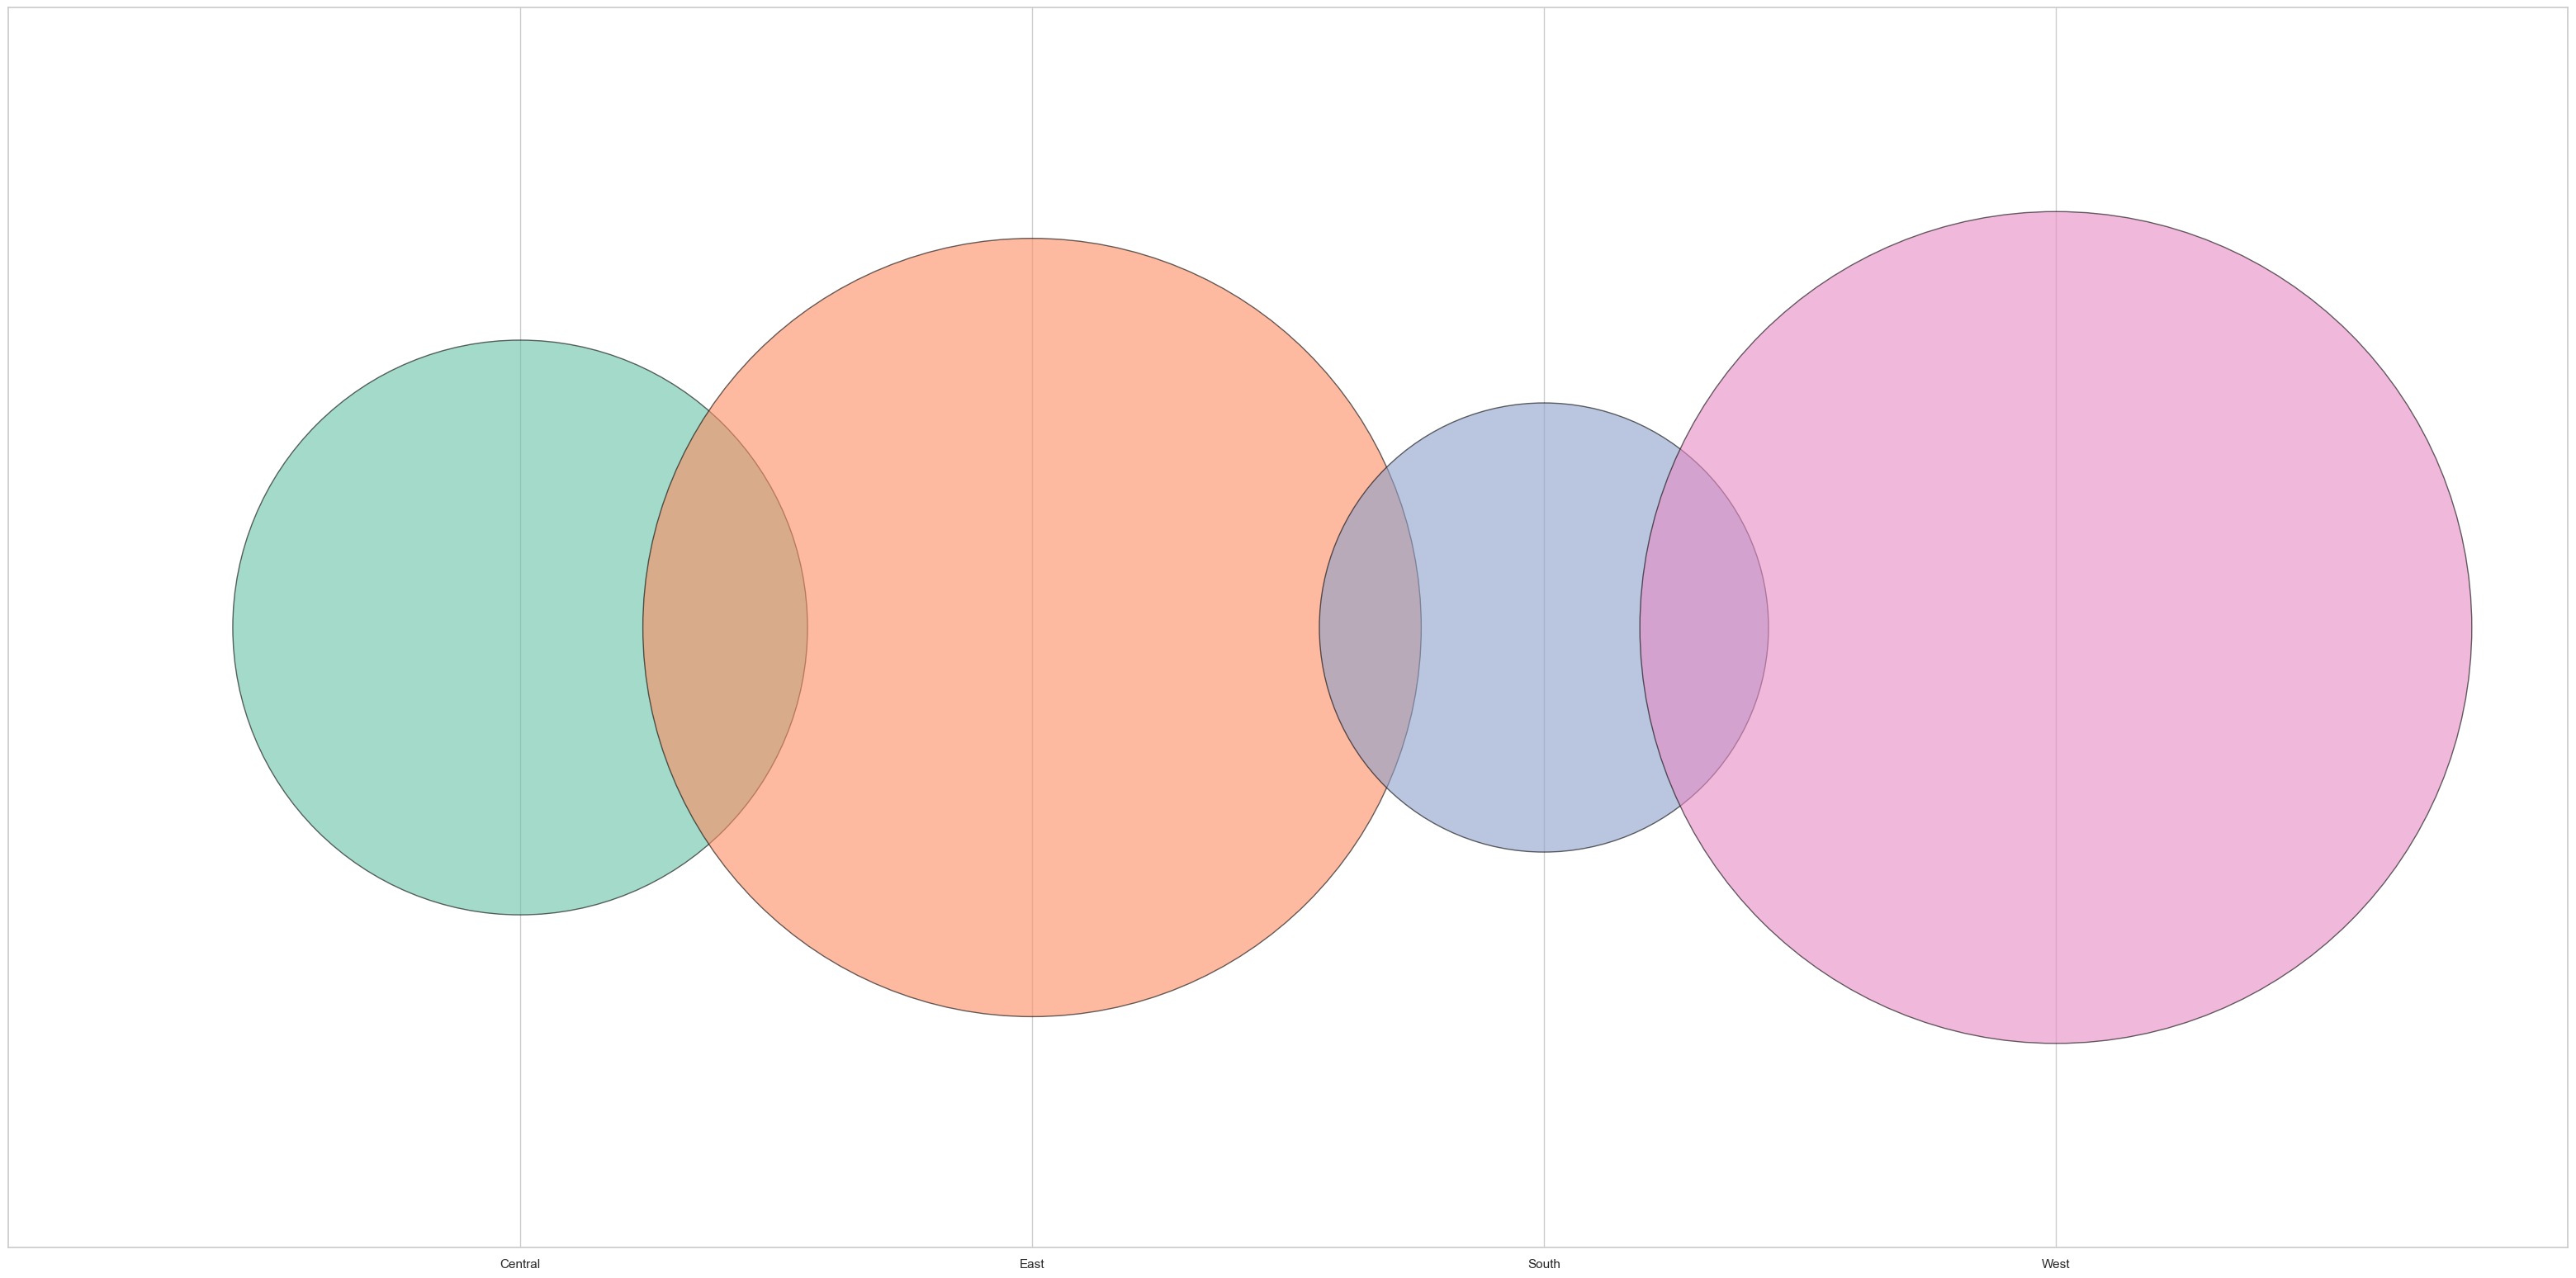

In [79]:
#task 6

region_sales = df.groupby('Region')['Sales'].sum().reset_index()

plt.figure(figsize=(7, 4.5))
sns.barplot(data=region_sales, x='Region', y='Sales')
plt.ylim(350000, 750000) 
plt.ylabel('Total Sales')
plt.show()
#truncated y axis now it disproportionately shows and exaggerates how small south and central are


df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_data = df.groupby(df['Order Date'].dt.to_period('M'))[['Sales', 'Profit']].sum().sort_index()
monthly_data.index = monthly_data.index.astype(str)
fig, ax1 = plt.subplots(figsize=(12, 5))
# Plot first measure (Sales) on Left Y-Axis
color = 'tab:blue'
ax1.set_xlabel('Month Timeline')
ax1.set_ylabel('Total Monthly Sales ($)', color=color)
ax1.plot(monthly_data.index, monthly_data['Sales'], color=color, marker='o', alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(monthly_data.index, rotation=45, ha='right')
#Overlaying an independent secondary axis
ax2 = ax1.twinx()  
#Plot completely different scale measure (Profit) on Right Y-Axis
color = 'tab:green'
ax2.set_ylabel('Net Monthly Profit ($)', color=color)
ax2.plot(monthly_data.index, monthly_data['Profit'], color=color, marker='s', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)
plt.show()

#here 2 completely independent columns are plotted on same axis and it looks like they have some correlation 




df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly_profit = df.groupby(df['Order Date'].dt.to_period('M'))['Profit'].sum().sort_index()
monthly_profit.index = monthly_profit.index.astype(str)

plt.figure(figsize=(11, 4))
plt.plot(monthly_profit.index, monthly_profit.values)
plt.gca().invert_yaxis() 

plt.xlabel('Month Timeline')
plt.ylabel('Net Profit')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()
#now axis are inverted so its misleading as up should mean the profit went up



monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().sort_index()
monthly_sales = monthly_sales.reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].astype(str)
#Cherry-picking a negative window
cherry_picked_data = monthly_sales.iloc[8:12]
plt.figure(figsize=(6, 4))
plt.plot(cherry_picked_data['Order Date'], cherry_picked_data['Sales'], color='darkblue', marker='s', linewidth=2)
plt.xlabel('Month Timeline')
plt.ylabel('Total Monthly Sales')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

#we used only a tiny window that shows a huge decline in sales to mislead that sales have only gone down and hide the actual trend


x_positions = np.arange(len(region_sales))
y_positions = np.zeros(len(region_sales))
plt.figure(figsize=(40, 19.5))

#Scaling scatter markers by 'Radius Squared' via the s (Area) parameter
radius_distortion = (region_sales['Sales'] / 1000) ** 2
plt.scatter(x_positions, y_positions, s=radius_distortion, alpha=0.6, c=['#66c2a5','#fc8d62','#8da0cb','#e78ac3'], edgecolors='black')
plt.xticks(x_positions, region_sales['Region'])
plt.yticks([])
plt.xlim(-1, len(region_sales))
plt.ylim(-1, 1)
plt.show()

#we made it scale with radius not area so the area is very exaggerated and looks like a huge difference to us

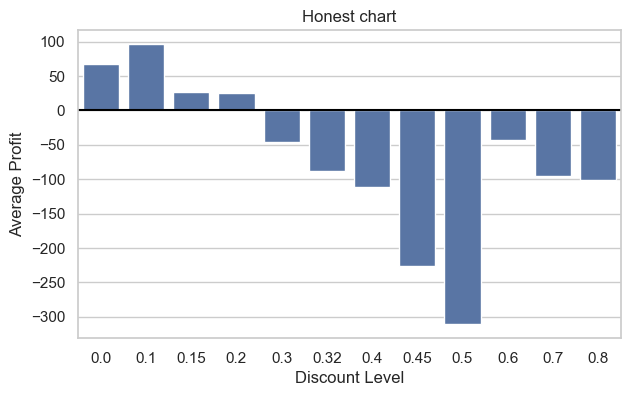

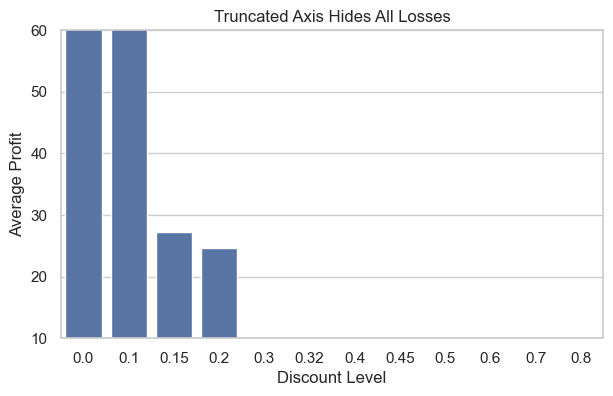

In [84]:
#task 6

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='Discount', y='Profit', errorbar=None)

plt.axhline(0, color='black', linewidth=1.5)
plt.title('Honest chart', fontsize=12)
plt.xlabel('Discount Level')
plt.ylabel('Average Profit')
plt.show()





plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='Discount', y='Profit', errorbar=None)
plt.ylim(10, 60) 
plt.title('Truncated Axis Hides All Losses', fontsize=12)
plt.xlabel('Discount Level')
plt.ylabel('Average Profit')
plt.show()


#bar chart is justified as we can directly see and tell and compare against different discount levels and their average profit
#truncating it hides all the losses so it is highly misleading and it looks like there is no loss at all 
#this dark blue has a good contrast so it is all visible and accessable